In [1]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
%matplotlib inline

plt.rcParams["figure.figsize"] = (16, 9)

In [3]:
# Get the raw data
df_nhl = pd.read_csv("../data/nhl_season_goals.csv")

In [4]:
df_nhl.dropna().head()

,rank,position,hand,player,years,total_goals,status,yr_start,season,age,...,goals,assists,points,plus_minus,penalty_min,goals_even,goals_power_play,goals_short_handed,goals_game_winner,headshot
3,1,C,Left,Wayne Gretzky,1979-99,894,Retired,1979,1979-80,19,...,51,86,137,14.0,21,37.0,13.0,1.0,6.0,https://d9kjk42l7bfqz.cloudfront.net/req/20191...
4,1,C,Left,Wayne Gretzky,1979-99,894,Retired,1979,1980-81,20,...,55,109,164,41.0,28,36.0,15.0,4.0,3.0,https://d9kjk42l7bfqz.cloudfront.net/req/20191...
5,1,C,Left,Wayne Gretzky,1979-99,894,Retired,1979,1981-82,21,...,92,120,212,80.0,26,68.0,18.0,6.0,12.0,https://d9kjk42l7bfqz.cloudfront.net/req/20191...
6,1,C,Left,Wayne Gretzky,1979-99,894,Retired,1979,1982-83,22,...,71,125,196,61.0,59,47.0,18.0,6.0,9.0,https://d9kjk42l7bfqz.cloudfront.net/req/20191...
7,1,C,Left,Wayne Gretzky,1979-99,894,Retired,1979,1983-84,23,...,87,118,205,78.0,39,55.0,20.0,12.0,11.0,https://d9kjk42l7bfqz.cloudfront.net/req/20191...


In [5]:
df_nhl["player"].unique().shape

(251,)

In [6]:
df_nhl_cluster = df_nhl.dropna()
df_nhl_avg = (
    df_nhl_cluster[
        [
            "player",
            "goals",
            "assists",
            "points",
            "plus_minus",
            "penalty_min",
            "goals_even",
            "goals_power_play",
            "season_games",
        ]
    ]
    .groupby(["player"])
    .mean()
    .reset_index()
)
# ['goals','assists','points','plus_minus','penalty_minutes','goals_even','goals_power_play'].mean()
df_nhl_avg.head()

,player,goals,assists,points,plus_minus,penalty_min,goals_even,goals_power_play,season_games
0,Adam Oates,15.880000,51.280000,67.160000,0.600000,19.160000,10.720000,4.600000,63.080000
1,Al MacInnis,14.782609,40.608696,55.391304,16.130435,65.695652,7.130435,7.217391,61.565217
2,Alex Delvecchio,21.066667,39.133333,60.200000,1.600000,13.466667,15.000000,5.466667,67.800000
3,Alex Ovechkin,46.666667,38.000000,84.666667,5.333333,47.933333,29.133333,17.266667,76.333333
4,Alex Tanguay,16.166667,33.722222,49.888889,9.500000,31.055556,12.277778,3.500000,64.333333


In [7]:
df_nhl_avg.info()

<class 'pandas.DataFrame'>
RangeIndex: 163 entries, 0 to 162
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   player            163 non-null    str    
 1   goals             163 non-null    float64
 2   assists           163 non-null    float64
 3   points            163 non-null    float64
 4   plus_minus        163 non-null    float64
 5   penalty_min       163 non-null    float64
 6   goals_even        163 non-null    float64
 7   goals_power_play  163 non-null    float64
 8   season_games      163 non-null    float64
dtypes: float64(8), str(1)
memory usage: 11.6 KB


array([[<Axes: xlabel='goals', ylabel='goals'>,
        <Axes: xlabel='assists', ylabel='goals'>,
        <Axes: xlabel='points', ylabel='goals'>,
        <Axes: xlabel='plus_minus', ylabel='goals'>,
        <Axes: xlabel='penalty_min', ylabel='goals'>,
        <Axes: xlabel='goals_even', ylabel='goals'>,
        <Axes: xlabel='goals_power_play', ylabel='goals'>,
        <Axes: xlabel='season_games', ylabel='goals'>],
       [<Axes: xlabel='goals', ylabel='assists'>,
        <Axes: xlabel='assists', ylabel='assists'>,
        <Axes: xlabel='points', ylabel='assists'>,
        <Axes: xlabel='plus_minus', ylabel='assists'>,
        <Axes: xlabel='penalty_min', ylabel='assists'>,
        <Axes: xlabel='goals_even', ylabel='assists'>,
        <Axes: xlabel='goals_power_play', ylabel='assists'>,
        <Axes: xlabel='season_games', ylabel='assists'>],
       [<Axes: xlabel='goals', ylabel='points'>,
        <Axes: xlabel='assists', ylabel='points'>,
        <Axes: xlabel='points', ylabel='

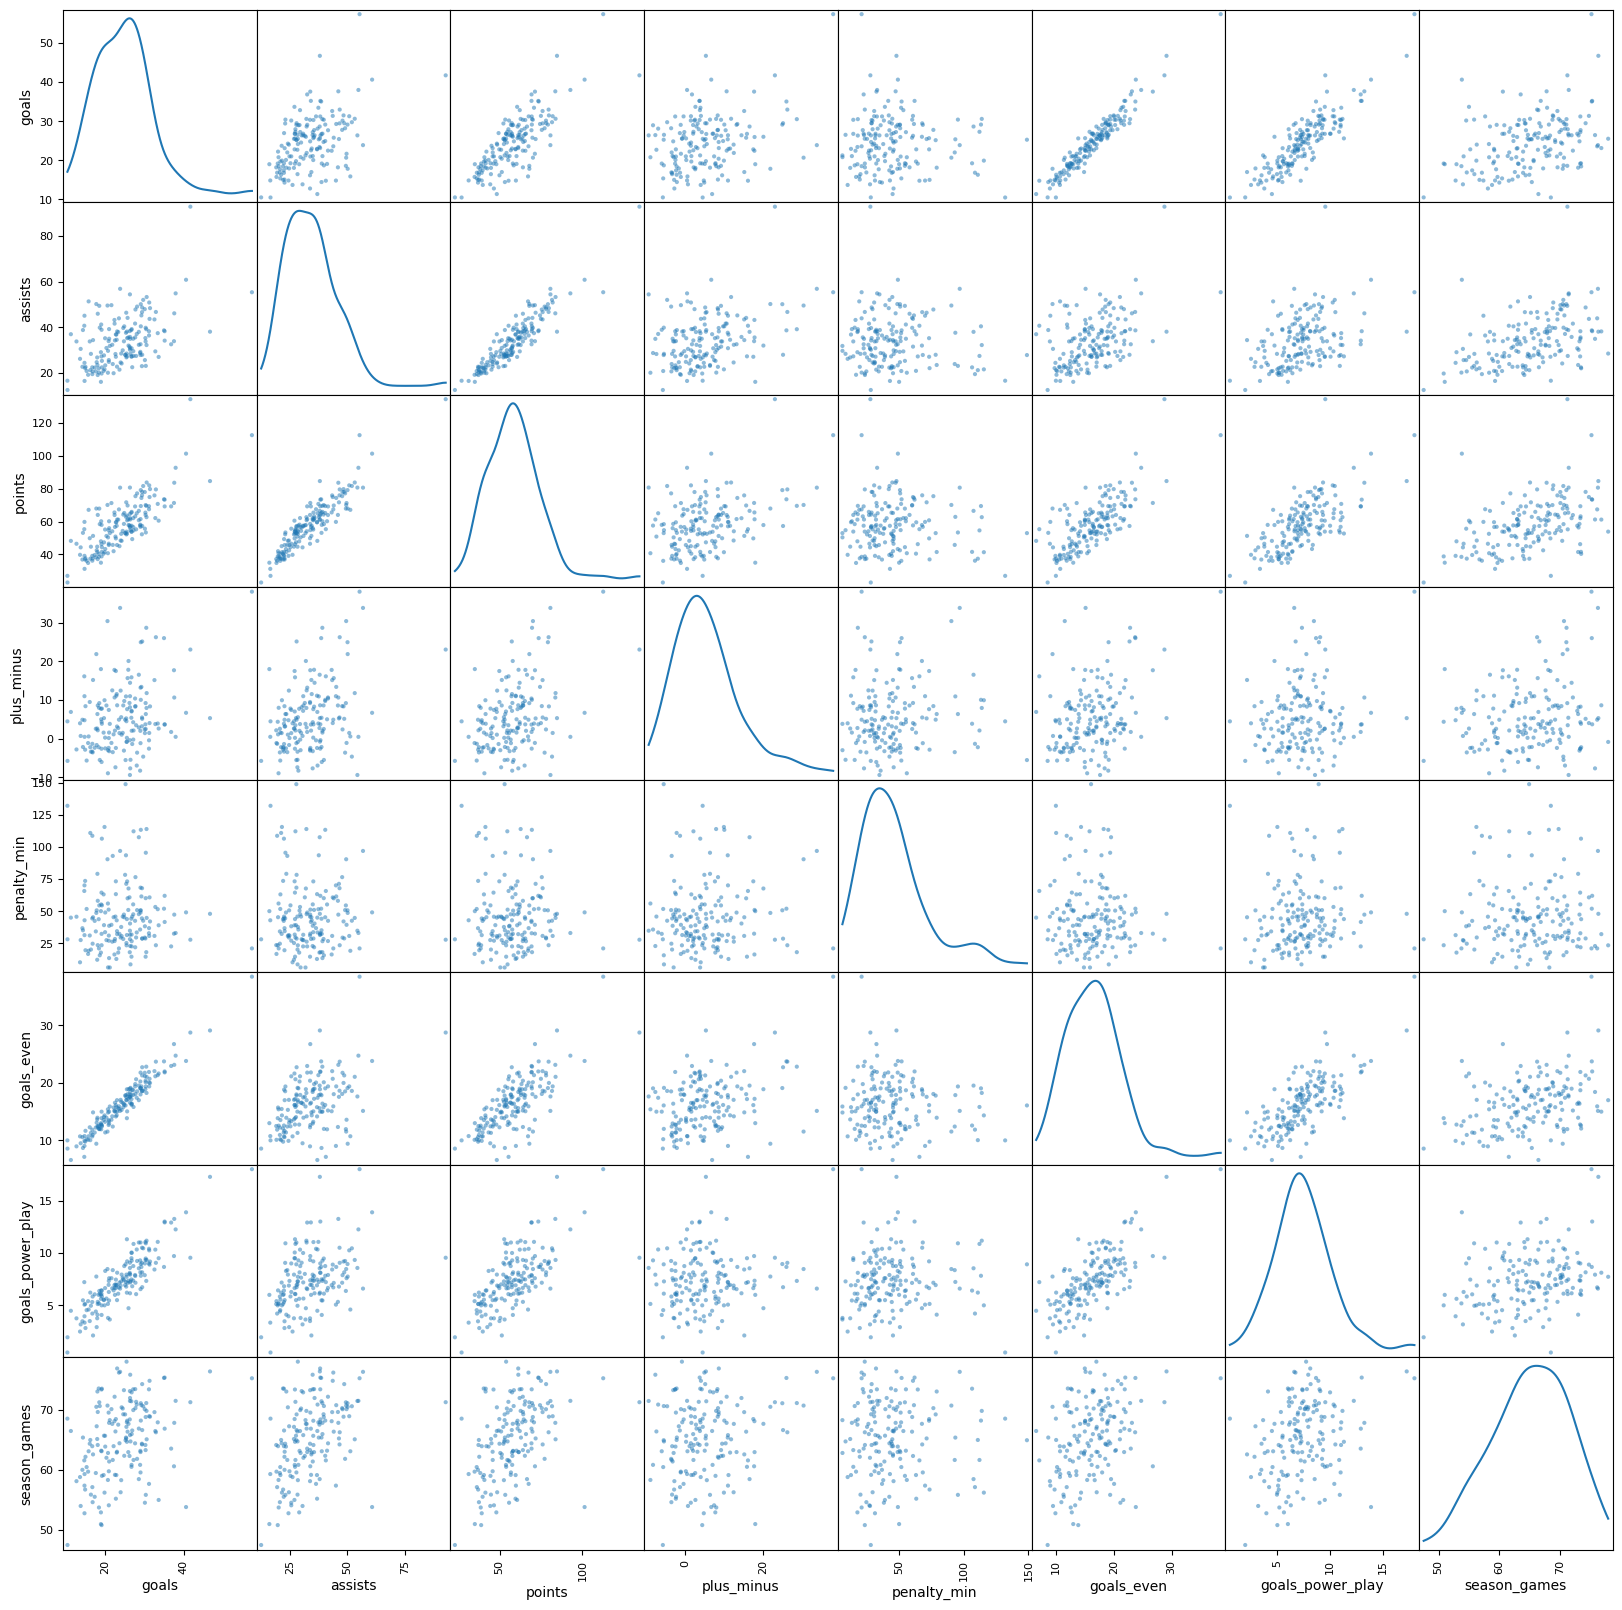

In [8]:
from pandas.plotting import scatter_matrix

scatter_matrix(df_nhl_avg, figsize=(20, 20), diagonal="kde")

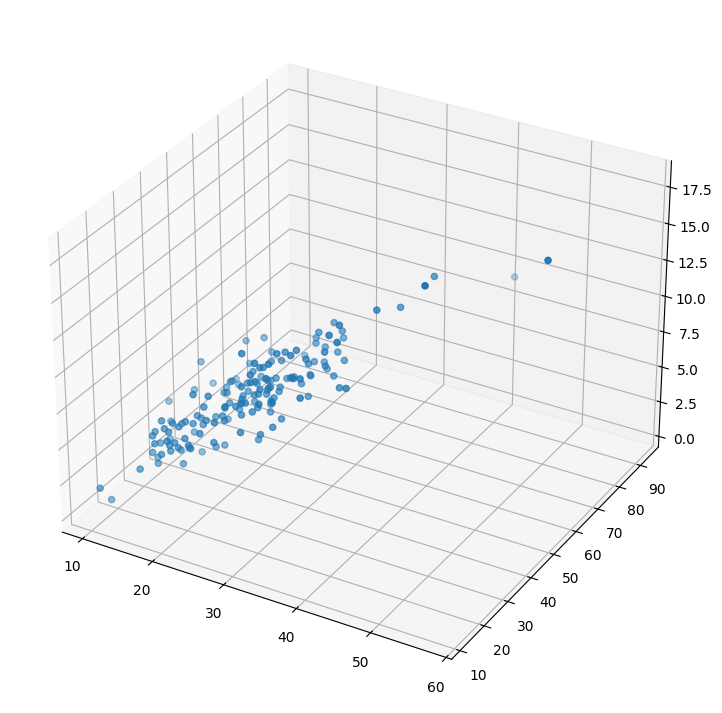

In [9]:
fig = plt.figure()
# ax = Axes3D(fig)
ax = fig.add_subplot(111, projection="3d")
ax.scatter(df_nhl_avg["goals"], df_nhl_avg["assists"], df_nhl_avg["goals_power_play"])

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(
    df_nhl_avg[
        [
            "goals",
            "assists",
            "points",
            "plus_minus",
            "penalty_min",
            "goals_even",
            "goals_power_play",
        ]
    ]
)

In [11]:
X = df_nhl_cluster[
    [
        "goals",
        "assists",
        "points",
        "plus_minus",
        "penalty_min",
        "goals_even",
        "goals_power_play",
    ]
]

In [12]:
sse = {}
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000, random_state=42).fit(X_scaled)
    # data["clusters"] = kmeans.labels_
    print(kmeans.labels_)
    sse[k] = (
        kmeans.inertia_
    )  # Inertia: Sum of distances of samples to their closest cluster center

print(sse)

[1 1 1 0 1 0 1 0 0 1 1 0 1 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 1 0 0 1 0 0 0 0 1
 0 0 0 1 0 1 1 1 0 1 0 0 1 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 1 0 0 0
 0 0 1 0 1 1 0 0 1 0 1 0 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 1 0 0 0 1 0 0 0 1 0 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 0 1 0 0
 1 0 0 1 0 0 1 1 1 0 1 1 0 0 1]
[2 2 1 0 2 1 2 1 1 1 1 0 2 0 2 0 1 2 1 2 0 2 1 1 0 2 1 1 1 0 1 2 1 1 1 1 2
 1 1 1 2 1 1 2 2 1 1 0 1 2 2 2 0 1 0 0 2 1 1 0 2 1 0 1 1 2 2 1 1 1 2 1 1 1
 1 0 1 1 1 2 1 1 2 1 2 1 2 0 0 2 1 0 1 1 1 1 0 2 2 0 0 2 2 1 1 1 1 2 1 2 2
 1 1 0 1 2 2 2 1 1 1 2 1 1 0 2 1 2 1 2 2 1 2 1 1 2 1 1 1 2 2 2 1 2 0 2 1 1
 2 0 0 2 1 1 2 2 2 1 2 2 0 1 1]
[1 1 1 3 1 0 1 1 0 1 1 0 2 0 2 0 0 1 0 2 0 2 0 0 0 2 0 1 0 0 1 2 1 0 0 0 1
 0 1 0 2 0 1 2 2 0 0 0 0 2 2 2 0 0 0 0 1 1 0 0 2 0 0 0 0 2 1 0 0 1 2 0 0 0
 0 0 1 0 1 2 0 0 2 0 2 0 1 0 3 2 0 3 0 1 0 1 0 2 2 0 3 2 2 0 0 0 2 2 0 2 2
 0 1 0 0 2 1 1 0 0 1 1 0 0 3 1 0 2 1 2 2 0 2 0 0 1 1 1 1 2 2 2 1 2 0 2 0 0
 2 0 0 2 0 0 2 2 2 0 2 2 3 0 0]
[1 1

Let's see if elbow methods can help us determine the optimal number of clusters here.


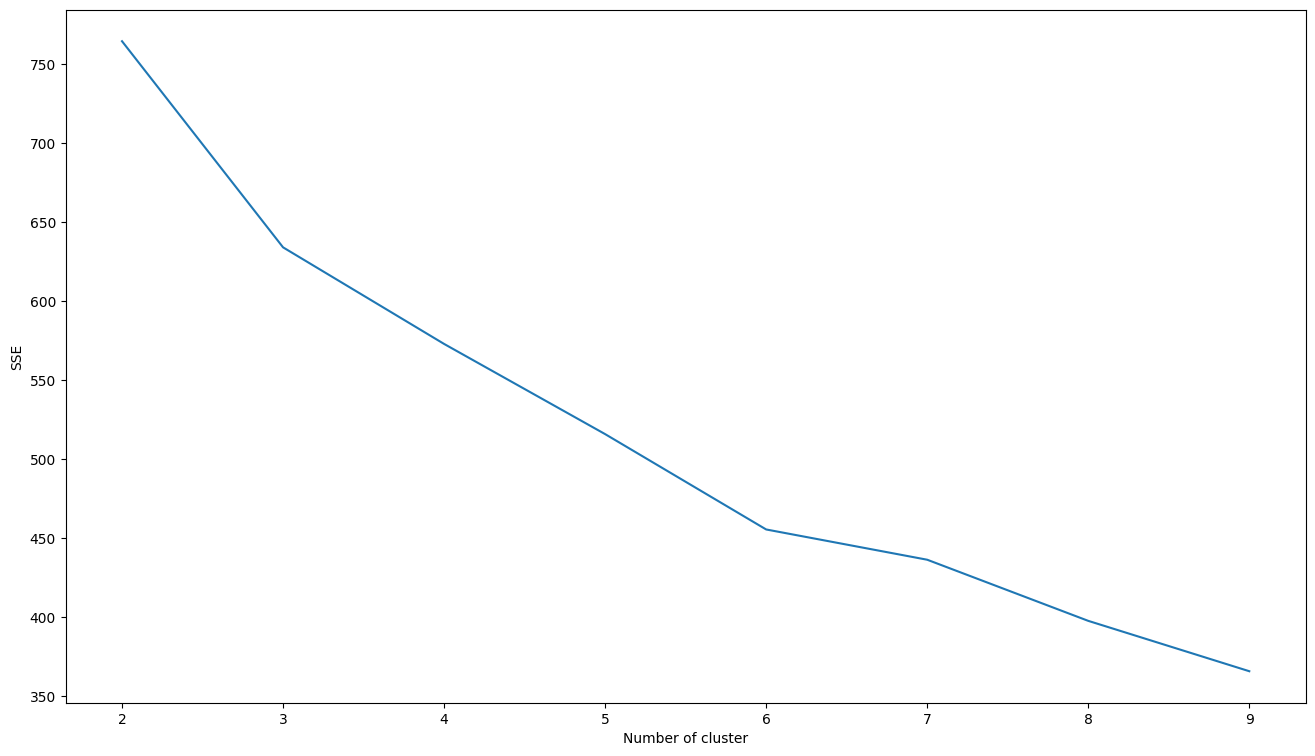

In [13]:
plt.figure()
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Number of cluster")
plt.ylabel("SSE")
plt.show()

As you see, there isn't any clear elbow points on the graph. It is often the case with real-world data when you try to do kmeans cluster. Looking at what an elbow means, which stands for the point who has the biggest difference of slope before and after, we could say maybe 3 clusters is a good option.

However, we have other ways to determine the number of optimal clusters: silhouette coefficient. It measures the cohesion and separation of clusters. It quantifies how well a data point fits into its assigned cluster based on the following two factors:

- How close the data point is to other points in the cluster?
- How far away the data point is from points in other clusters?

The values of silhouette coefficient range between -1 and 1, with larger numbers indicating that samples are closer to their clusters than they are to other clusters.

The average silhouette coefficient of the entire dataset can be used as a single point of comparison between different cluster numbers. You can call it the silhouette score. The `scikit-learn` package provides an easy way to calculate the silhouette score using the `silhouette score()` function.


In [14]:
silhouette_scores = {}
for n_clusters in range(2, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(X_scaled)
    # data["clusters"] = kmeans.labels_
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores[n_clusters] = score
    print(f"For n_clusters = {n_clusters}, silhouette score is {score}")


For n_clusters = 2, silhouette score is 0.165219521090392
For n_clusters = 3, silhouette score is 0.19270550723883145
For n_clusters = 4, silhouette score is 0.1847675384777404
For n_clusters = 5, silhouette score is 0.20425141855104764
For n_clusters = 6, silhouette score is 0.19035194979094036
For n_clusters = 7, silhouette score is 0.19397690143849405
For n_clusters = 8, silhouette score is 0.17397174474974256
For n_clusters = 9, silhouette score is 0.193204571123589


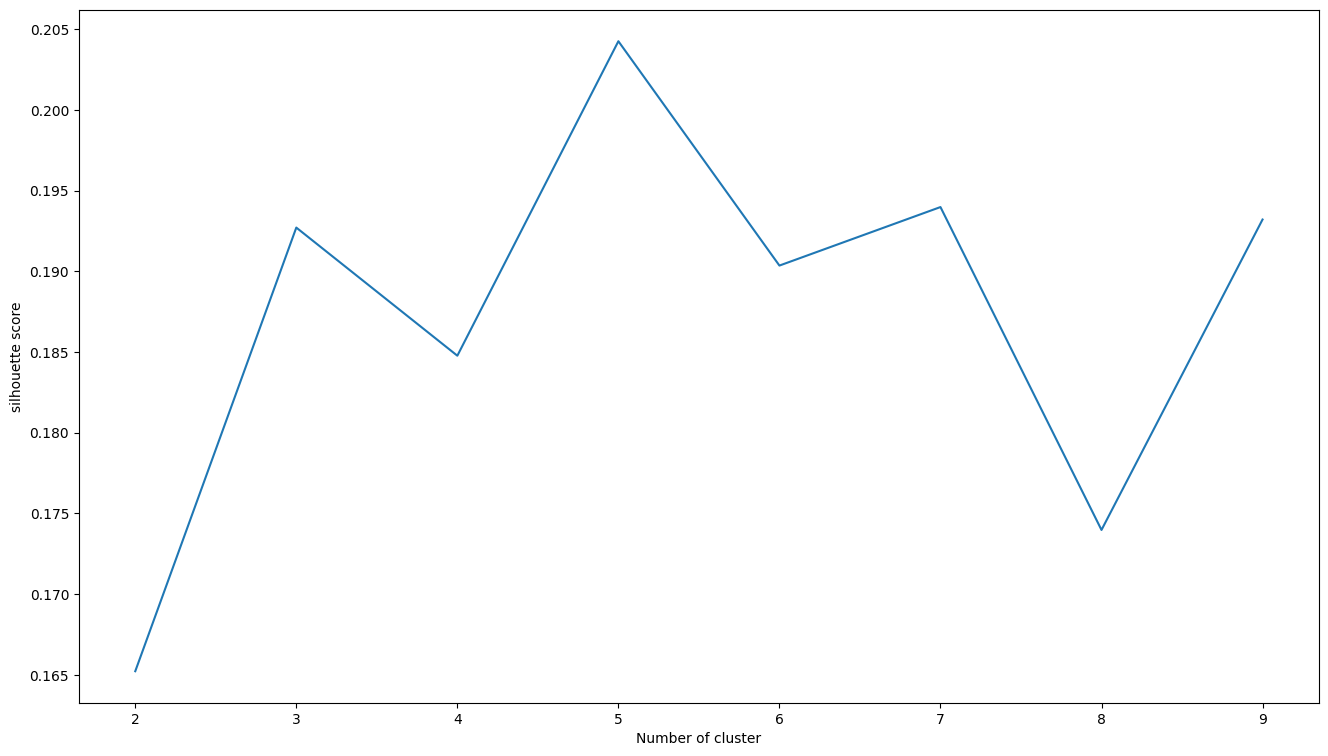

In [15]:
plt.figure()
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()))
plt.xlabel("Number of cluster")
plt.ylabel("silhouette score")
plt.show()

Looking at the silhouette score, we can pick 2 as the optimal cluster number purely becasue it has the highest silhouette score, which means the points are closer to their assigned cluster and away from other cluster. It could be the answer to how many clusters should we have. But, ultimately, your decision on the number of clusters to use should be guided by **a combination of domain knowledge and clustering evaluation metrics.**

So that's important to look at what each cluster actually means. We will look at the center of each cluster, it usually gives us a good idea of what the cluster represent. In this case, let's look at what the clusters mean if we choose k = 3


In [16]:
# 3 cluster scenario
kmeans_3 = KMeans(n_clusters=3, max_iter=1000, random_state=42).fit(X_scaled)
df_nhl_avg["clusters_3"] = kmeans_3.labels_
cluster_centers_3 = scaler.inverse_transform(kmeans_3.cluster_centers_)
df_centers_3 = pd.DataFrame(
    cluster_centers_3,
    columns=[
        "goals",
        "assists",
        "points",
        "plus_minus",
        "penalty_min",
        "goals_even",
        "goals_power_play",
    ],
)
df_centers_3

,goals,assists,points,plus_minus,penalty_min,goals_even,goals_power_play
0,34.480554,47.472821,81.953375,12.208659,42.927834,22.712865,10.619472
1,25.998762,34.883776,60.882538,5.835761,46.858877,17.225859,8.052654
2,17.732589,26.249725,43.982315,1.971616,44.970301,12.148895,5.028639
